# O que é o Pré-processamento

É a etapa onde preparamos os dados para que os modelos
de Machine Learning consigam consumir e aprender com eles.

Os modelos trabalham com numeros e não entendem "Yes/No", "Sales Executive" ou "Jovem/Adulto/Senior", na qual são variáveis categóricas. Nessa etapa realizaremos: 
- Encondings
- Separação entre feature e target
- Tratamento do desbalanceamento
- Divisão entre treino/teste

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset com features
df = pd.read_csv('../data/processed/ibm_hr_analytics_feature_engineering.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000000, 43)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,CriticalSatisfactionFlag,RatioCareerCompany,RoleStagnation,YearsWithoutPromotion,AgeGroup,IncomePerLevel,IncomeMedianJob,OverTime_encoded,RiskOvertimeDistance,RiskWorklifeOvertime
0,56,No,Travel_Rarely,590,Research & Development,19,1,Other,4,Female,...,0,0.852941,0.366667,0.366667,Senior,4126.00,1.175722,1,19,3
1,46,No,Travel_Rarely,1441,Human Resources,5,1,Life Sciences,4,Male,...,0,0.973684,0.157895,0.131579,Senior,9987.00,0.951324,1,5,2
2,32,Yes,Travel_Frequently,748,Research & Development,2,3,Medical,4,Male,...,0,0.592593,0.176471,0.882353,Adulto,638.00,0.121478,0,0,0
3,60,No,Travel_Rarely,1311,Human Resources,3,4,Life Sciences,2,Female,...,0,0.966667,0.566667,0.200000,Senior,451.75,0.173001,0,0,0
4,25,No,Non-Travel,144,Sales,10,4,Life Sciences,4,Male,...,0,0.260870,0.285714,0.857143,Jovem,7317.50,1.393279,0,0,0


## Vamos separar as features (x) e target (y)

X = todas as variáveis que o modelo vai usar para aprender (features originais + novas features)

y = A variável que o modelo vai tentar prever (Attrition → 0 ou 1)

- X (maiusculo) -> é uma matriz (muitas colunas e linhas)
- y (minusculo) -> é um vetor (uma única coluna)

In [2]:
# Colunas que nao devem entrar como features
colunas_remover = ['Attrition', 'AttritionFlag']

# Separar X e y
y = df['AttritionFlag']
X = df.drop(columns=colunas_remover)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny distribuição:")
print(y.value_counts(normalize=True).round(4) * 100)

# Podemos observar que a distribuição permaneceu a mesma do dataset original

X shape: (1000000, 41)
y shape: (1000000,)

y distribuição:
AttritionFlag
0    83.99
1    16.01
Name: proportion, dtype: float64


In [3]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Categóricas: {cat_cols}")
print(f"Numéricas: {num_cols}")
print()
print(f'Total de variáveis categóricas: {len(cat_cols)}')
print(f'Total de variáveis numéricas: {len(num_cols)}')

Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'AgeGroup']
Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'SatisfactionScore', 'CriticalSatisfactionFlag', 'RatioCareerCompany', 'RoleStagnation', 'YearsWithoutPromotion', 'IncomePerLevel', 'IncomeMedianJob', 'OverTime_encoded', 'RiskOvertimeDistance', 'RiskWorklifeOvertime']

Total de variáveis categóricas: 8
Total de variáveis numéricas: 33


In [4]:
# Vamos remover o OverTime_encoded , pois foi utilizado apenas na etapa de calculo na etapa de feature engineering
# OverTime_encoded e OverTime são as mesmas informações, manter as duas gera redundância, pois vamos aplicar a técnica de OneHotEncoder em OverTime (yes, no).

X = X.drop(columns=['OverTime_encoded'])
num_cols.remove('OverTime_encoded')

print(f"X shape atualizado: {X.shape}")
print(f"Numéricas: {len(num_cols)}")
print(f"Categóricas: {len(cat_cols)}")

X shape atualizado: (1000000, 40)
Numéricas: 32
Categóricas: 8


### Anotações Pessoais

### Diferenças entre X_train, X_test, y_train, y_test**

**Treinamento**

É com os dois conjuntos X_train e y_train que o modelo vai passar pelo processo de aprendizagem. Nós passamos para ele as features e o resultado real de attrtition, como se fosse em
um aluno estudando para uma prova com um gabarito em mãos. Nessa etapa o modelo vai aprender com as features e os resultados reais dos funcionários.

**Teste**

Após a etapa de treinamento acima, vamos precisar descobrir se o modelo aprendeu a identificar os funcionários que podem entrar em attrition. Para esse cenário, vamos trabalhar com o conjunto X_test e sem apresentar 
a resposta real para o modelo. Ele simplesmente vai ler as features e tentar realizar a previsão de attrition.

Nessa etapa queremos ver o que o modelo aprendeu. E para validar essas respostas, usaremos o conjunto y_test, que seria o gabarito real. Ainda no exemplo do aluno, a etapa de teste
é como se fosse a prova, e o aluno vai responder as questões sem o gabarito, e no final será feito a correção para ver qual foi a nota do aluno com base no gabarito com todas as respostas corretas.

### Por qual motivo manter as mesmas distribuições no split?

É necessário manter a mesma distribuição do dataset real na etapa de split treino e teste para que o modelo aprenda com base no dataset real e não de forma aleatória. 

Dataset original:  84% No / 16% Yes (1.000.000 registros)

Split aleatório SEM stratify pode gerar:
- Treino: 90% No / 10% Yes  = poucos exemplos de Yes para aprender
- Teste:  70% No / 30% Yes  = muitos exemplos de Yes para avaliar

Com esse desbalanceamento no split aleatório podemos enviesar a resposta do modelo, já que ele aprendeu com peso maior em uma categoria.

In [5]:
# Split treino/teste (80/20) com estratificação para manter as proporções corretas entre yes e no

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\ny_train distribuição:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print(f"\ny_test distribuição:")
print(y_test.value_counts(normalize=True).round(4) * 100)

# Podemos analisar que mantivemos a distibuição do dataset real.

X_train: (800000, 40)
X_test:  (200000, 40)

y_train distribuição:
AttritionFlag
0    83.99
1    16.01
Name: proportion, dtype: float64

y_test distribuição:
AttritionFlag
0    83.99
1    16.01
Name: proportion, dtype: float64


Transformação StandardScaler: Essa transformação resolve o problema das escalas das variáveis numéricas. Essas variáveis tem escalas bem diferentes uma das outras. Exemplo:
- Age:           18 a 60        (dezenas)
- MonthlyIncome: 1.009 a 19.999  (milhares)
- DistanceFromHome: 1 a 29      (dezenas)
- IncomePerLevel: 200 a 19.999  (centenas a milhares)

Sem transformação:
- A Regressão Logística dá mais peso para variáveis com valores grandes (MonthlyIncome) simplesmente porque os números são maiores e não porque são mais importantes

- Variáveis com valores pequenos (Age) ficam "invisíveis" para o modelo, mesmo que sejam relevantes na hora da predição.

Para cada variável, transforma os valores para que:
- A média fique em 0
- O desvio padrão fique em 1

Fórmula: valor_novo = (valor_original - média) / desvio_padrão

Resultado:
- Valores ficam centralizados em 0
- Todas as variáveis passam a ter a mesma escala
- O modelo consegue comparar Age com MonthlyIncome de forma justa

Observação: Mesmo que apenas um dos modelos é impactado, caso não tenha essa trasnformação, os demais modelos não são prejudicados com essas escalas.

In [6]:
# Preprocessador: aplica transformações diferentes por tipo de coluna
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, recall_score,
    f1_score, precision_score, roc_auc_score, balanced_accuracy_score,
    matthews_corrcoef, ConfusionMatrixDisplay, RocCurveDisplay
)

import time

# MODELO 1 - Regressão Logística

Técnica de desbalanceamento: class_weight='balanced'

O dataset possui desbalanceamento de classes (84% No / 16% Yes). Sem tratamento, o modelo tenderia a prever "No" para a maioria dos casos, pois acertaria 84% das vezes simplesmente ignorando 
classe minoritária (Yes). O class_weight='balanced' resolve isso ajustando o peso de cada classe automaticamente:
- A classe Yes (minoritária) recebe peso maior
- A classe No (majoritária) recebe peso menor
- O modelo passa a penalizar mais os erros na classe Yes, forçando a aprender a identificar quem sai da empresa

Parâmetros do modelo:
- class_weight='balanced': tratamento do desbalanceamento
- max_iter=1000: número máximo de iterações para convergência, aumentado do padrão (100) devido ao volume do dataset (1M)
- random_state=42: garante reprodutibilidade dos dados

Pipeline:
- O preprocessor (StandardScaler + OneHotEncoder) é aplicado
automaticamente antes do modelo, dentro do mesmo Pipeline

In [8]:
pipeline_rl = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Treinar
start = time.time()
pipeline_rl.fit(X_train, y_train)
train_time = time.time() - start

print(f"Tempo de treino: {train_time:.2f}s")
print("Modelo treinado com sucesso!")

Tempo de treino: 9.33s
Modelo treinado com sucesso!


In [9]:
# ============================================
# AVALIAÇÃO — Regressão Logística
# ============================================

# Previsões
y_pred_rl = pipeline_rl.predict(X_test)
y_pred_proba_rl = pipeline_rl.predict_proba(X_test)[:, 1]

# Métricas
recall = recall_score(y_test, y_pred_rl)
precision = precision_score(y_test, y_pred_rl)
f1 = f1_score(y_test, y_pred_rl)
roc_auc = roc_auc_score(y_test, y_pred_proba_rl)

print("=" * 55)
print("  REGRESSÃO LOGÍSTICA — Resultados")
print("=" * 55)
print(f"  {'Métrica':<25} {'Valor':>10}")
print("-" * 55)
print(f"  {'Recall (Yes)':<25} {recall:>10.4f}")
print(f"  {'Precision (Yes)':<25} {precision:>10.4f}")
print(f"  {'F1-Score (Yes)':<25} {f1:>10.4f}")
print(f"  {'ROC-AUC':<25} {roc_auc:>10.4f}")
print("=" * 55)


  REGRESSÃO LOGÍSTICA — Resultados
  Métrica                        Valor
-------------------------------------------------------
  Recall (Yes)                  0.5001
  Precision (Yes)               0.1594
  F1-Score (Yes)                0.2417
  ROC-AUC                       0.4976


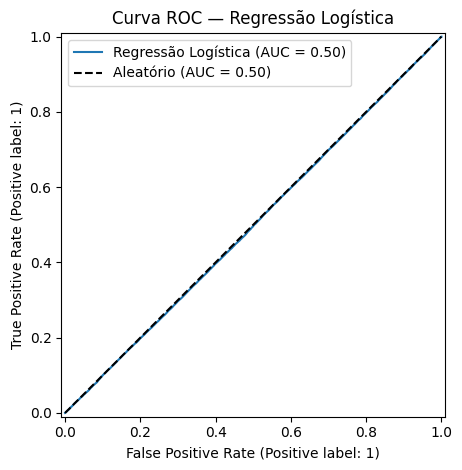

In [14]:
# Curva ROC — Regressão Logística
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba_rl,
    name='Regressão Logística'
)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.title('Curva ROC — Regressão Logística')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/curva_roc_rl.png', dpi=150, bbox_inches='tight')
plt.show()

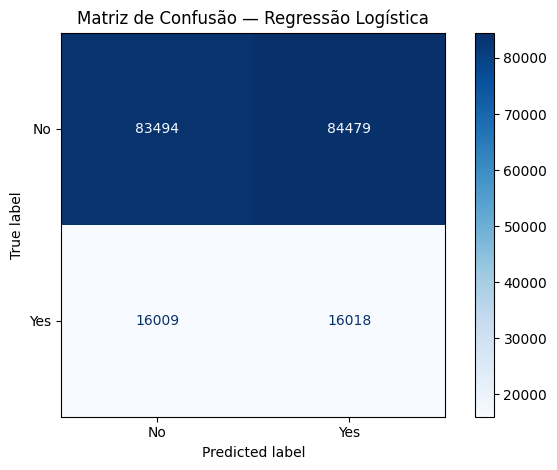

In [11]:
# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rl,
    display_labels=['No', 'Yes'],
    cmap='Blues'
)
plt.title('Matriz de Confusão — Regressão Logística')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_rl.png', dpi=150, bbox_inches='tight')
plt.show()

## Análise da modelagem

- Ao analisarmos os resultados, vemos que o modelo está se comportando praticamente de forma aleatória. Temos resultado de ROC-AUC igual à 0.49 que está abaixo de 0.50, ou seja, é quase jogar uma moeda
e cair um valor aleatório. A métrica Recall (Yes) tem o valor de 0.50, ou seja, o modelo acertou metade e errou metade, isso confirma que o modelo está gerando resultados aleatórios.


Olhando a matriz de confusão:
- Dos 167.973 que ficaram (No), acertou 83.494 e errou 84.479 (praticamente 50/50)
- Dos 32.027 que saíram (Yes), acertou 16.018 e errou 16.009 (praticamente 50/50)

Concluímos que o modelo está basicamente chutando para os dois lados.

De certa forma, esse resultado já era esperado. Nenhuma das variáveis originais apresentou correlação com Attrition e mesmo aplicando a etapa de Feature Engineering, nenhuma nova feature melhorou a correlação. E realizando as validações estatísticas, apenas 1 das 30 variáveis apresentou pequena significancia.

Se os dados não tem relação com a target, nenhum modelo consegue aprender padrões. Concluímos que o modelo de Regressão Logística está prevendo muito abaixo do esperado, confirmando o que havíamos analisado na 
etapa da análise exploratória.


# MODELO 2 - Random Forest

Random Forest é um modelo baseado em árvore de decisão que captura relações não lineares e interações entre variáveis. Diferente do modelo de Regressão Logística, não há relação linear entre feature e target.

Estamos realizando a mesma técnica de desbalanceamento dos dados aplicando pesos a target Attrition.

In [ ]:
# Parâmetros:
# class_weight='balanced': tratamento do desbalanceamento
# n_estimators=100: número de árvores no ensemble
# n_jobs=-1: usa todos os núcleos do processador (mais rápido)
# random_state=42: reprodutibilidade

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Treinar
start = time.time()
pipeline_rf.fit(X_train, y_train)
train_time_rf = time.time() - start

print(f"Tempo de treino: {train_time_rf:.2f}s")
print("Modelo treinado com sucesso!")

Tempo de treino: 142.90s
Modelo treinado com sucesso!


In [16]:
# ============================================
# AVALIAÇÃO — Random Forest
# ============================================

# Previsões
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Métricas
recall = recall_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("=" * 55)
print("  RANDOM FOREST — Resultados")
print("=" * 55)
print(f"  {'Métrica':<25} {'Valor':>10}")
print("-" * 55)
print(f"  {'Recall (Yes)':<25} {recall:>10.4f}")
print(f"  {'Precision (Yes)':<25} {precision:>10.4f}")
print(f"  {'F1-Score (Yes)':<25} {f1:>10.4f}")
print(f"  {'ROC-AUC':<25} {roc_auc:>10.4f}")
print("=" * 55)

  RANDOM FOREST — Resultados
  Métrica                        Valor
-------------------------------------------------------
  Recall (Yes)                  0.0000
  Precision (Yes)               0.0000
  F1-Score (Yes)                0.0000
  ROC-AUC                       0.4977


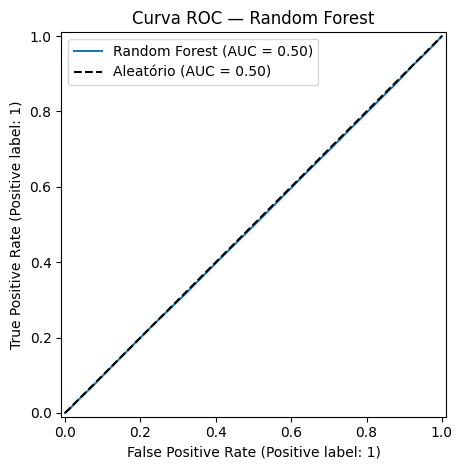

In [18]:
# Curva ROC — Random Forest
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba_rf,
    name='Random Forest'
)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.title('Curva ROC — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/curva_roc_rf.png', dpi=150, bbox_inches='tight')
plt.show()

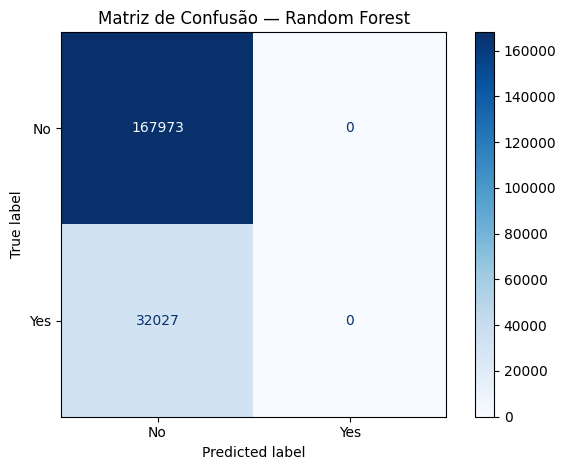

In [17]:
# Matriz de confusão — Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No', 'Yes'],
    cmap='Blues'
)
plt.title('Matriz de Confusão — Random Forest')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## Análise da modelagem — Random Forest

- Ao analisarmos os resultados, vemos que o modelo apresentou desempenho inferior a Regressão Logística. O ROC-AUC é igual a 0.4977, praticamente aleatório. As métricas Recall (Yes), Precision (Yes) e F1-Score (Yes)
são todas iguais a 0.0000, ou seja, o modelo não identificou nenhum funcionário que saiu da empresa.

Olhando a matriz de confusão:
- Dos 167.973 que ficaram (No), acertou 167.973 e errou 0 (acertou 100%)
- Dos 32.027 que saíram (Yes), acertou 0 e errou 32.027 (errou 100%)

Concluímos que o modelo previu "No" para todos os 200.000 registros de teste, sem arriscar um único "Yes". Mesmo com o parâmetro class_weight='balanced' para tratar o desbalanceamento e com a capacidade de capturar relações não-lineares através de 100 árvores de decisão, o Random Forest não encontrou nenhum padrão nos dados que justificasse prever "Yes".

Enquanto a Regressão Logística chutou aleatoriamente (50/50), o Random Forest optou por classificar todos como "No", garantindo 84% de accuracy mas 0% de Recall, reforçando que Accuracy não é uma boa métrica para datasets desbalanceados, conforme discutimos no Business Understanding.

Esse resultado reforça a conclusão anterior: a limitação está nos dados (sem relação entre features e target), não na capacidade dos modelos.